# Project KTB1: dLCA of Lovastatin Production

**Author**: ADA ROBINSON
**Date**: 2025-01-05  
**Environment**: `pharma`
**Software & Library Versions**
- Brightway25 version 1.0.6  
- bw2io version 0.9.4  
- Numpy version 1.24.4  
- Python version 3.11.11
  
**Data Sources**:  
- Ecoinvent v3.10 (cut-off system)  
- KTB1 model (DTU)

---

## Project Overview
> **What**: This notebook focuses on **electricity demand** 

> **How**: 

> **Why (Intended Outcome)**: 

---

> **Note**: 



### Brightway imports

In [493]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bw2io as bi
import bw2calc as bc
import bw2data as bd
import bw2analyzer as ba
import os
import brightway2 as bw

### Temporalis imports

In [494]:
import bw_graph_tools as graph
from bw_temporalis import (
    easy_timedelta_distribution, 
    easy_datetime_distribution, 
    TemporalisLCA, 
    Timeline, 
    TemporalDistribution
)
from bw_temporalis.lcia import characterize_methane, characterize_co2

## Importing and Preparing Process Data

In [495]:
DATA_DIR = r"C:\Users\arobinson\Desktop\DynamicLCA\Inventories"
infile = os.path.join(DATA_DIR, "lci_pharma_dynamic.csv") #infile will always have the same name. 
                                              #If the inventories within the datsbase need update, a new database is created, change the name of the old datbase for backup
                                              #rename the new one "\lci_pharma_dynamic.csv" to keep the script consistent
df = pd.read_csv(infile,usecols=[0,1,2,3,4]) #Skips the first row of the file. Specifies which columns to load (by their index positions). #, skiprows=1
df.columns = [col.lower() for col in df.columns] #Converts all column names to lowercase
df = df.rename(columns={#Renames columns to more meaningful and Python-friendly names.
    "time": "Time",
    'data_1': "CSTR", 
    'data_2': "Hydrocyclone", 
    'data_3': "Centrifuge", 
    'data_4': "Pump",
})
df['Total'] = (
    df['CSTR'] 
    + df['Hydrocyclone'] 
    + df['Centrifuge'] 
    + df['Pump']
)
df = df.iloc[:24]
df

,Time,CSTR,Hydrocyclone,Centrifuge,Pump,Total
0,0,22.19214,2.19562,13.62883,5.86381,43.88040
1,1,22.19214,1.16313,13.62883,5.86381,42.84791
2,2,19.80610,1.16313,13.62886,5.75665,40.35474
3,3,20.00377,1.62519,13.62888,5.77763,41.03547
4,4,20.05318,2.00616,13.62891,5.78951,41.47776
5,5,20.05994,2.06662,13.62893,5.79874,41.55423
6,6,20.05995,2.06684,13.62895,5.80735,41.56309
7,7,20.05995,2.06733,13.62898,5.81569,41.57195
8,8,20.05996,2.06811,13.62900,5.82387,41.58094
9,9,20.05997,2.06897,13.62902,5.83194,41.58990


In [496]:
print(len(df)) #print(len(df.columns))

24


Text(0.5, 1.0, 'Dynamic LCA Inventory')

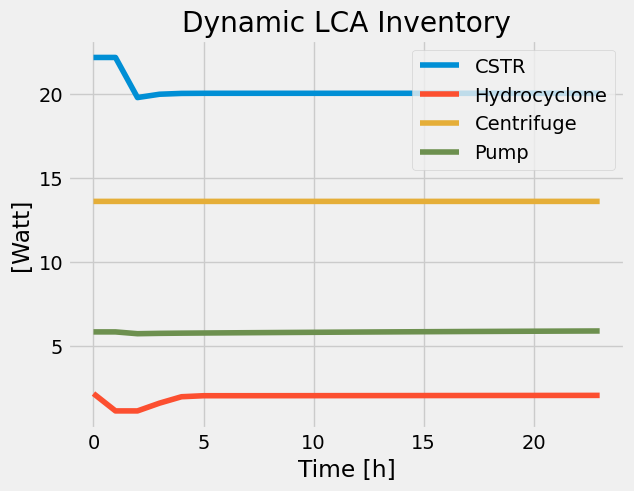

In [497]:
df.iloc[:,1:5].plot()
plt.xlabel('Time [h]')
plt.ylabel('[Watt]')
plt.title('Dynamic LCA Inventory')

In [498]:
#sns.pairplot(df.iloc[:,1:]) #The plot displays pairwise scatter plots for all numerical variables in the DataFrame.
                              #Diagonal Plots show histograms for each individual variable, representing their distributions.
                              #Off-Diagonal Plots are scatter plots showing relationships between two variables.

## Importing and Preparing Environmental Impact Databases

### ecoinvent

In [16]:
bi.import_ecoinvent_release('3.10', 'cutoff', 'adarobinsonmedici', 'Ecoinvent37725921!')

Applying strategy: normalize_units
Applying strategy: drop_unspecified_subcategories
Applying strategy: ensure_categories_are_tuples
Applied 3 strategies in 0.02 seconds
Graph statistics for `ecoinvent-3.10-biosphere` importer:
4362 graph nodes:
	emission: 4000
	natural resource: 344
	inventory indicator: 13
	economic: 5
0 graph edges:
0 edges to the following databases:
0 unique unlinked edges (0 total):




100%|███████████████████████████████████████████████████████████████████████████| 4362/4362 [00:00<00:00, 18302.58it/s]


16:50:20 [info     ] Vacuuming database            
Created database: ecoinvent-3.10-biosphere
Extracting XML data from 23523 datasets
16:51:26 [info     ] Extracted 23523 datasets in 64.29 seconds
Applying strategy: normalize_units
Applying strategy: update_ecoinvent_locations
Applying strategy: remove_zero_amount_coproducts
Applying strategy: remove_zero_amount_inputs_with_no_activity
Applying strategy: remove_unnamed_parameters
Applying strategy: es2_assign_only_product_with_amount_as_reference_product
Applying strategy: assign_single_product_as_activity
Applying strategy: create_composite_code
Applying strategy: drop_unspecified_subcategories
Applying strategy: fix_ecoinvent_flows_pre35
Applying strategy: drop_temporary_outdated_biosphere_flows
Applying strategy: link_biosphere_by_flow_uuid
Applying strategy: link_internal_technosphere_by_composite_code
Applying strategy: delete_exchanges_missing_activity
Applying strategy: delete_ghost_exchanges
Applying strategy: remove_uncertain

100%|███████████████████████████████████████████████████████████████████████████| 23523/23523 [01:04<00:00, 366.80it/s]


16:52:40 [info     ] Vacuuming database            
Created database: ecoinvent-3.10-cutoff


### electricity types databese - ab

In [499]:
bw.create_core_migrations()

In [500]:
imp = bw.ExcelImporter(r"C:\Users\arobinson\Desktop\DynamicLCA\Inventories\elect_db_dk_ab.xlsx")
imp.apply_strategies()
imp.match_database("ecoinvent-3.10-cutoff", fields=('name','unit','location','reference product'))
imp.match_database(fields=('name','unit','location'))
imp.statistics()

# Specify your desired path & filename in `fp`:
imp.write_excel(
    r"C:\Users\arobinson\Desktop\DynamicLCA\Inventories\elect_db_dk_unlinked_flows.xlsx"
)
list(imp.unlinked)

imp.write_database()

Extracted 1 worksheets in 0.06 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: normalize_biosphere_categories
Applying strategy: normalize_biosphere_names
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 16 strategies in 0.21 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Graph statistics for `Electricity KTB1` importer:
8 graph nodes:
	process: 8
235 graph 

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 192.13it/s]


17:26:45 [info     ] Vacuuming database            
Created database: Electricity KTB1


# ATTENTION HERE!

In [501]:
SEED_DATABASE = "ecoinvent-3.10-cutoff"

if 'electricity_ktb1' not in [project.name for project in list(bd.projects)]:
    bd.projects.set_current(SEED_DATABASE)
    bd.projects.copy_project('electricity_ktb1', switch=True)
else:
    bd.projects.set_current('electricity_ktb1')

bd.databases

Databases dictionary with 2 object(s):
	ecoinvent-3.10-biosphere
	ecoinvent-3.10-cutoff

In [502]:
list(bw.projects)

[Project: default,
 Project: new_project,
 Project: pharma,
 Project: Pharma_2,
 Project: hydrogen,
 Project: [BW25] default,
 Project: [BW25] hydrogen,
 Project: [BW25] pharma,
 Project: [BW25] new_project,
 Project: Electricity Generation per production type - BZNIDK2,
 Project: electricity_ktb1,
 Project: my_new_project,
 Project: dds-MFA]

In [503]:
bw.projects.set_current('[BW25] pharma') 

In [504]:
bd.databases

Databases dictionary with 5 object(s):
	Electricity KTB1
	KTB1_dynamic
	biosphere3
	ecoinvent-3.10-cutoff
	electricity_ktb1

In [505]:
el_dk_1 =  bw.Database('electricity_ktb1')

In [506]:
el_prod_dk_1 = [a for a in el_dk_1 if 'electricity' or 'heat' in a ['name']]
el_prod_dk_1

['heat and power co-generation, hard coal' (megajoule, DK, None),
 'electricity production, wind, 1-3MW turbine, offshore' (kilowatt hour, DK, None),
 'electricity production, wind, >3MW turbine, onshore' (kilowatt hour, DK, None),
 'electricity production, photovoltaic, 3kWp slanted-roof installation, multi-Si, panel, mounted' (kilowatt hour, DK, None),
 'electricity production, oil' (kilowatt hour, DK, None),
 'electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt hour, DK, None),
 'heat and power co-generation, biogas, gas engine' (kilowatt hour, DK, None),
 'heat and power co-generation, natural gas, conventional power plant, 100MW electrical' (megajoule, DK, None)]

In [507]:
#activities_as_dicts = [act.as_dict() for act in el_prod_dk_1]
#activities_as_dicts

In [508]:
activities_info = []
for act in el_prod_dk_1:
    # You decide which keys you want to include or rename
    d = {
        'name': act['name'],
        'amount': 1,  # or some real value
        'database': act['database'],
        'location': act['location'],
        'unit': act['unit'],
        'type': act.get('type', 'unknown'),  # or "production"/"technosphere" as needed
        'reference product': act.get('reference product', None),
    }
    activities_info.append(d)

activities_info

[{'name': 'heat and power co-generation, hard coal',
  'amount': 1,
  'database': 'electricity_ktb1',
  'location': 'DK',
  'unit': 'megajoule',
  'type': 'process',
  'reference product': 'heat, district or industrial, other than natural gas'},
 {'name': 'electricity production, wind, 1-3MW turbine, offshore',
  'amount': 1,
  'database': 'electricity_ktb1',
  'location': 'DK',
  'unit': 'kilowatt hour',
  'type': 'process',
  'reference product': 'electricity, high voltage'},
 {'name': 'electricity production, wind, >3MW turbine, onshore',
  'amount': 1,
  'database': 'electricity_ktb1',
  'location': 'DK',
  'unit': 'kilowatt hour',
  'type': 'process',
  'reference product': 'electricity, high voltage'},
 {'name': 'electricity production, photovoltaic, 3kWp slanted-roof installation, multi-Si, panel, mounted',
  'amount': 1,
  'database': 'electricity_ktb1',
  'location': 'DK',
  'unit': 'kilowatt hour',
  'type': 'process',
  'reference product': 'electricity, low voltage'},
 {'na

### methods

In [509]:
#list(bw.methods)

In [510]:
recipe = [m for m in bw.methods if 'ReCiPe' in str(m) and 'ecosystem' in str(m) and 'total' in str(m) and 'endpoint (E)' in str(m) and 'LT' not in str(m)] 
recipe

[('ReCiPe 2016 v1.03, endpoint (E)',
  'total: ecosystem quality',
  'ecosystem quality')]

## Importing and Preparing Electricity Generation per Production Type Database

In [511]:
e_dk = pd.read_csv(r"C:\Users\arobinson\Desktop\DynamicLCA\Inventories\20250114_elect_dk.csv")
e_dk.head(2)

,Area,MTU,Biomass - Actual Aggregated [MW],Fossil Brown coal/Lignite - Actual Aggregated [MW],Fossil Coal-derived gas - Actual Aggregated [MW],Fossil Gas - Actual Aggregated [MW],Fossil Hard coal - Actual Aggregated [MW],Fossil Oil - Actual Aggregated [MW],Fossil Oil shale - Actual Aggregated [MW],Fossil Peat - Actual Aggregated [MW],...,Hydro Run-of-river and poundage - Actual Aggregated [MW],Hydro Water Reservoir - Actual Aggregated [MW],Marine - Actual Aggregated [MW],Nuclear - Actual Aggregated [MW],Other - Actual Aggregated [MW],Other renewable - Actual Aggregated [MW],Solar - Actual Aggregated [MW],Waste - Actual Aggregated [MW],Wind Offshore - Actual Aggregated [MW],Wind Onshore - Actual Aggregated [MW]
0,Denmark (DK),14.01.2025 00:00 - 14.01.2025 01:00 (CET/CEST),579,n/e,n/e,137,262,34,n/e,n/e,...,n/e,n/e,n/e,n/e,n/e,n/e,0,76,2223,3420
1,Denmark (DK),14.01.2025 01:00 - 14.01.2025 02:00 (CET/CEST),534,n/e,n/e,138,261,28,n/e,n/e,...,n/e,n/e,n/e,n/e,n/e,n/e,0,75,2223,3359


### Sum of total electricity production per hour

In [512]:
# Replace 'n/e' with 0 and convert to numeric BEFORE summing:
e_dk.iloc[:, 2:] = (
    e_dk.iloc[:, 2:]
    .replace('n/e', 0)
    .apply(pd.to_numeric, errors='coerce')
)

C:\Users\arobinson\AppData\Local\Temp\ipykernel_30920\3461010918.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace('n/e', 0)


In [513]:
# Convert the time or hour into a simple integer index 
e_dk['MTU'] = range(len(e_dk))

In [514]:
# Select only numeric columns among the columns 2: onwards
cols_to_sum = e_dk.iloc[:, 2:].select_dtypes(include='number').columns

In [515]:
# Now sum only these numeric columns
e_dk['Sum_elec_prod'] = e_dk[cols_to_sum].sum(axis=1)

In [516]:
e_dk.head(2)

,Area,MTU,Biomass - Actual Aggregated [MW],Fossil Brown coal/Lignite - Actual Aggregated [MW],Fossil Coal-derived gas - Actual Aggregated [MW],Fossil Gas - Actual Aggregated [MW],Fossil Hard coal - Actual Aggregated [MW],Fossil Oil - Actual Aggregated [MW],Fossil Oil shale - Actual Aggregated [MW],Fossil Peat - Actual Aggregated [MW],...,Hydro Water Reservoir - Actual Aggregated [MW],Marine - Actual Aggregated [MW],Nuclear - Actual Aggregated [MW],Other - Actual Aggregated [MW],Other renewable - Actual Aggregated [MW],Solar - Actual Aggregated [MW],Waste - Actual Aggregated [MW],Wind Offshore - Actual Aggregated [MW],Wind Onshore - Actual Aggregated [MW],Sum_elec_prod
0,Denmark (DK),0,579,0,0,137,262,34,0,0,...,0,0,0,0,0,0,76,2223,3420,6731
1,Denmark (DK),1,534,0,0,138,261,28,0,0,...,0,0,0,0,0,0,75,2223,3359,6618


In [517]:
#e_dk2.shape 
#e_dk2.info

### Percentage of production type generated per hour

In [518]:
e_dk2 = e_dk.dropna(axis=1)

In [519]:
# This will be useful when uploading an yearly database. Slice the 24-hour rows (assuming exactly 24 rows), numeric columns only
df_day1 = e_dk.iloc[0:24, 2:-1]

# Calculate sums per column
sums_day1 = df_day1.sum(axis=1)

# Replace zeros in sums with NaN, to avoid division-by-zero
sums_day1 = sums_day1.replace({0: np.nan})

# Compute percentage of each cell relative to column total
percentage1 = df_day1.div(sums_day1, axis=0).fillna(0)

# Rename and add these percentage columns into e_dk
percentage1 = percentage1.add_suffix('_pct')  # e.g. "Biomass - Actual Aggregated [MW]_pct"
e_dk[percentage1.columns] = percentage1

# Export the percentage table alone if you like
#percentage1.to_csv('e_dk_perc.csv', index=False)

C:\Users\arobinson\AppData\Local\Temp\ipykernel_30920\466323771.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sums_day1 = sums_day1.replace({0: np.nan})
C:\Users\arobinson\AppData\Local\Temp\ipykernel_30920\466323771.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  percentage1 = df_day1.div(sums_day1, axis=0).fillna(0)


In [520]:
percentage1["Sum_elec_prod_pct"] = (
    percentage1.drop(columns="Sum_elec_prod_pct", errors='ignore')
    .sum(axis=1)
)

In [521]:
percentage1.head(2)

,Biomass - Actual Aggregated [MW]_pct,Fossil Brown coal/Lignite - Actual Aggregated [MW]_pct,Fossil Coal-derived gas - Actual Aggregated [MW]_pct,Fossil Gas - Actual Aggregated [MW]_pct,Fossil Hard coal - Actual Aggregated [MW]_pct,Fossil Oil - Actual Aggregated [MW]_pct,Fossil Oil shale - Actual Aggregated [MW]_pct,Fossil Peat - Actual Aggregated [MW]_pct,Geothermal - Actual Aggregated [MW]_pct,Hydro Pumped Storage - Actual Aggregated [MW]_pct,...,Hydro Water Reservoir - Actual Aggregated [MW]_pct,Marine - Actual Aggregated [MW]_pct,Nuclear - Actual Aggregated [MW]_pct,Other - Actual Aggregated [MW]_pct,Other renewable - Actual Aggregated [MW]_pct,Solar - Actual Aggregated [MW]_pct,Waste - Actual Aggregated [MW]_pct,Wind Offshore - Actual Aggregated [MW]_pct,Wind Onshore - Actual Aggregated [MW]_pct,Sum_elec_prod_pct
0,0.086020,0.0,0.0,0.020354,0.038924,0.005051,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.011291,0.330263,0.508097,1.0
1,0.080689,0.0,0.0,0.020852,0.039438,0.004231,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.011333,0.335902,0.507555,1.0


In [522]:
print(len(percentage1)) 
#print(len(percentage1.columns))

24


In [523]:
#print(df_day1.dtypes)

In [524]:
# print(percentage1.head(24))

## Mapping Dictionary - Generation technology with environmental impact

In [541]:
mapping = {
    "Fossil Hard coal - Actual Aggregated [MW]_pct":
        ("electricity_ktb1", "heat and power co-generation, hard coal"),
    "Fossil Oil - Actual Aggregated [MW]_pct":
        ("electricity_ktb1", "electricity production, oil"),
    "Fossil Gas - Actual Aggregated [MW]_pct":
        ("electricity_ktb1", "heat and power co-generation, natural gas, conventional power plant, 100MW electrical"),
    "Wind Offshore - Actual Aggregated [MW]_pct":
        ("electricity_ktb1", "electricity production, wind, 1-3MW turbine, offshore"),
    "Wind Onshore - Actual Aggregated [MW]_pct":
        ("electricity_ktb1", "electricity production, wind, >3MW turbine, onshore"),
    "Biomass - Actual Aggregated [MW]_pct":
        ("electricity_ktb1", "heat and power co-generation, biogas, gas engine"),
    "Waste - Actual Aggregated [MW]_pct":
        ("electricity_ktb1", "electricity, from municipal waste incineration to generic market for electricity, medium voltage"),
    "Solar - Actual Aggregated [MW]_pct":
        ("electricity_ktb1", "electricity production, photovoltaic, 3kWp slanted-roof installation, multi-Si, panel, mounted"),
}

### Choose method

In [542]:
method = (
    "ReCiPe 2016 v1.03, endpoint (E)",
    "total: ecosystem quality",
    "ecosystem quality"
)
print("Using method:", method)

Using method: ('ReCiPe 2016 v1.03, endpoint (E)', 'total: ecosystem quality', 'ecosystem quality')


In [544]:
time_index = 0

In [545]:
cstr_consumption = df.loc[time_index, "CSTR"]  # e.g. 22.19214 (MW)

print(f"Hour={time_index} => CSTR consumption = {cstr_consumption} MW")

Hour=0 => CSTR consumption = 22.19214 MW


In [560]:
fu = {}
for pct_col, (db_name, act_name) in mapping.items():
    fraction = percentage1.loc[time_index, pct_col]  # e.g. 0.086 for biomass at hour=0
    if fraction == 0:
        continue  # skip zero shares to keep the FU cleaner

    # Actual consumption from this technology in MW:
    consumption_tech = fraction * cstr_consumption

    # Find the matching activity in `electricity_ktb1`
    db_activities = [act for act in bw.Database(db_name) if act["name"] == act_name]
    if not db_activities:
        print(f"**WARNING**: No activity named '{act_name}' found in DB '{db_name}'")
        continue

    # We'll pick the first match
    tech_act = db_activities[0]

    # Add to the functional unit dict
    # NOTE: If your dataset in ecoinvent is "per 1 kWh" or "per 1 MJ",
    #       interpret your MW values accordingly. This is just a test.
    fu[tech_act.key] = consumption_tech

print("Functional Unit dict for hour=0 (CSTR only):")
for k, v in fu.items():
    print(" ", k, " => ", v)

Functional Unit dict for hour=0 (CSTR only):
  ('electricity_ktb1', '5ea052f87997dc204d424e6a7b7ad9e9_copy1')  =>  0.8638152845045313
  ('electricity_ktb1', '166b0d4b81e1536db3b4e805f069854a_copy1')  =>  0.1120981666914277
  ('electricity_ktb1', 'f009cfa1fdeb3e3d6c571a183412a933_copy1')  =>  0.45168967166839996
  ('electricity_ktb1', '31e3b89b508cb5e8f76c1cb7dacfd3d6_copy1')  =>  7.329241898677759
  ('electricity_ktb1', '22f1bacf27ce65cb776db5866ae704fe_copy1')  =>  11.275756767196553
  ('electricity_ktb1', '071766ff40b7dea64310e903bea82ac8_copy1')  =>  1.9089658386569603
  ('electricity_ktb1', '78b0cf5613c6f5da6bc13f8f41d0a87b_copy1')  =>  0.2505723726043678


In [562]:
# Initialize the LCA:
lca = bw.LCA(
    demand=fu,
    method=method
)

# Build the technosphere and biosphere matrices
lca.lci()

# Perform LCIA (characterization)
lca.lcia()

# Print the total score
print(f"\n** LCA score for hour=0 (CSTR) => {lca.score} **")

AttributeError: 'NoneType' object has no attribute 'get'

In [561]:
lca = bc.LCA(fu, method=method)
lca.lci()
lca.lcia()

print(f"\n** LCA score for hour=0 (CSTR) => {lca.score} **")

AttributeError: 'NoneType' object has no attribute 'get'

### BUILD A SINGLE "KTB1 dynamic consumption" DATASET 

In [461]:
# We create one dataset: ("KTB1_dynamic", "KTB1 dynamic consumption").
# Then we add 32 exchanges. Each exchange is "Equipment X" & "Technology Y" 
# with a time distribution representing hour-by-hour consumption.

In [462]:
db_name = "KTB1_dynamic"
if db_name in bw.databases:
    del bw.databases[db_name]
ktb1_dyn_db = bw.Database(db_name)
ktb1_dyn_db.register()

In [463]:
dataset_key = (db_name, "KTB1 dynamic consumption")
ktb1_dataset = {
    dataset_key: {
        'name': "KTB1 dynamic consumption (24h)",
        'unit': 'megawatt hour',  # or 'megawatt' if you prefer
        'type': 'process',
        'exchanges': []
    }
}

In [464]:
# References to the underlying "electricity_ktb1" processes
def find_activity(db_name_mapped, act_name_mapped):
    db = bw.Database(db_name_mapped)
    found = [act for act in db if act["name"] == act_name_mapped]
    if not found:
        raise ValueError(f"Activity '{act_name_mapped}' not found in DB '{db_name_mapped}'")
    return found[0]

In [465]:
technology_activities = {
    tech_col: find_activity(db_name_mapped, act_name_mapped)
    for tech_col, (db_name_mapped, act_name_mapped) in mapping.items()
}

In [466]:
equipments = ["CSTR", "Hydrocyclone", "Centrifuge", "Pump"] # We have these 4 pieces of equipment in df

In [467]:
# We assume we want to match row i in df with row i in e_dk.
# So for hour i, df[equipment].iloc[i] is the consumption (MW),
# e_dk[technology_pct].iloc[i] is the fraction. 
# The final consumption from that technology at hour i:
#  consumption_tech[i] = df[equipment].iloc[i] * e_dk[technology_pct].iloc[i]
# We'll build a 25-element array (for i=0..24) 
# and store that as a TemporalDistribution.

In [468]:
# Step 1: Get references to the actual activities in `electricity_ktb1`
# We'll build a small dictionary to quickly find each (db, name).
# bd.prepare_lca_inputs()  # dont use in older versions of BW...
el_ktb1_db = bw.Database("electricity_ktb1")

In [469]:
# We'll gather (db, code) from the mapping. 
# Then for each key in mapping, we find the matching activity

In [470]:
def find_activity(db_name, name):
    db = bw.Database(db_name)
    results = [act for act in db if act["name"] == name]
    if not results:
        raise ValueError(f"Activity '{name}' not found in DB '{db_name}'!")
    return results[0]

In [471]:
technology_activities = {}
for tech_col, (db_name_mapped, act_name_mapped) in mapping.items():
    act = find_activity(db_name_mapped, act_name_mapped)
    technology_activities[tech_col] = act

In [472]:
exchanges_list = []
time_hours = np.array(df["Time"], dtype='timedelta64[h]')  # shape: (25,)

In [473]:
for eqp in equipments:
    for tech_col in mapping.keys():
        # Build the array of consumption for each of the 25 hours
        # If df[eqp].iloc[i] is in MW, and e_dk[tech_col].iloc[i] is fraction,
        # then consumption[i] in MW is df[eqp].iloc[i] * fraction.
        consumption_array = df[eqp].values * percentage1[tech_col].values

KeyError: 'Fossil Hard coal - Actual Aggregated [MW]_pct '

In [474]:
dist = TemporalDistribution(
            date=time_hours,
            amount=consumption_array
        )

In [255]:
total_amount = dist.total  # sum(consumption_array)

In [256]:
 exg = {
            'input': technology_activities[tech_col].key,  # from mapping
            'amount': total_amount, 
            'type': 'technosphere',
            'TemporalDistribution': dist,
            'unit': 'megawatt hour',  # or 'kilowatt hour' if you prefer
            'name': f"{eqp} via {tech_col}" 
            # e.g. "CSTR via Fossil Hard coal - Actual Aggregated [MW]_pct"
        }

In [257]:
 exchanges_list.append(exg)

In [258]:
ktb1_dataset[dataset_key]['exchanges'] = exchanges_list

In [259]:
ktb1_dyn_db.write(ktb1_dataset)

01:01:16 [warning  ] Not able to determine geocollections for all datasets. This database is not ready for regionalization.


100%|████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<?, ?it/s]


01:01:16 [info     ] Vacuuming database            


In [184]:
print(f"Created dataset with {len(exchanges_list)} exchanges. Done.")

Created dataset with 1 exchanges. Done.


# choose the method elswhere

In [185]:
method = (
    "ReCiPe Endpoint (Egalitarian) w/o LT",
    "climate change",
    "global warming"
)

### RUN A DYNAMIC LCA ON THE ENTIRE DAY

In [186]:
fu = {("KTB1_dynamic", "KTB1 dynamic consumption"): 1}

In [190]:
lca = bc.LCA(fu, method=method)

AttributeError: 'NoneType' object has no attribute 'get'

NameError: name 'lca' is not defined

In [228]:
import pprint
pprint.pprint(ktb1_dataset)

{('KTB1_dynamic', 'KTB1 dynamic consumption'): {'code': 'KTB1 dynamic '
                                                        'consumption',
                                                'database': 'KTB1_dynamic',
                                                'exchanges': [{'TemporalDistribution': TemporalDistribution instance with 24 values and total: 5.859,
                                                               'amount': 5.859241168164313,
                                                               'input': ('electricity_ktb1',
                                                                         'da3e8c4560d6d526cb7122e5957fc4b9_copy1'),
                                                               'name': 'Pump '
                                                                       'via '
                                                                       'Solar '
                                                                       '- '
                 

In [233]:
for exchange in ktb1_dataset[dataset_key]['exchanges'][:3]:  # Preview first 5 exchanges
    print(exchange)

{'input': ('electricity_ktb1', 'da3e8c4560d6d526cb7122e5957fc4b9_copy1'), 'amount': 5.859241168164313, 'type': 'technosphere', 'TemporalDistribution': TemporalDistribution instance with 24 values and total: 5.859, 'unit': 'megawatt hour', 'name': 'Pump via Solar - Actual Aggregated [MW]_pct', 'output': ('KTB1_dynamic', 'KTB1 dynamic consumption')}
